# Heart Disease Risk Prediction: Logistic Regression Homework

**Contexto introductorio :**
La enfermedad cardíaca es la principal causa de muerte a nivel mundial. En este ejercicio aplicamos regresión logística al dataset de Kaggle (303 pacientes) para practicar: EDA, implementación desde cero, visualización de fronteras de decisión, regularización L2 y un flujo conceptual de despliegue en Amazon SageMaker.

**Resumen del trabajo (pasos):**
1. Cargar y preparar datos: binarizar target, seleccionar features, manejar NA/outliers y normalizar.
2. Implementar regresión logística desde cero (sigmoid, costo, gradientes, descenso de gradiente).
3. Entrenar modelo baseline (λ=0) y analizar convergencia y métricas (ACC/PREC/REC/F1).
4. Visualizar fronteras de decisión para pares de features seleccionados (≥3 pares).
5. Añadir L2 (regularización), tunear λ y comparar métricas y `||w||` entre modelos.
6. Exportar mejor modelo y documentar pasos de despliegue en SageMaker (scripts, handler, endpoint).


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## 1. Carga y Preparación de Datos

**Explicación:**
- Cargamos el archivo CSV en un DataFrame de pandas e inspeccionamos su forma (*shape*), columnas y tipos de datos para asegurar que el conjunto de datos sea el esperado.
- La columna objetivo se binariza en `y` (1 = presencia de enfermedad, 0 = ausencia), convirtiendo el problema en uno de **clasificación binaria**.
- Se selecciona un conjunto pequeño e interpretable de características para mantener el modelo simple y permitir que las visualizaciones (como las fronteras de decisión) sean significativas.
- Se eliminan las filas con valores faltantes en las características seleccionadas para mantener la claridad en este cuaderno educativo; esto evita introducir sesgos por imputación al ilustrar los efectos de la regularización.

**Resultado:**
- `X`: Matriz de características con las columnas seleccionadas y sin valores nulos.
- `y`: Etiquetas binarias alineadas con `X`.

**Justificación:**
- Realizar una limpieza explícita y usar un conjunto pequeño de características ayuda a **aislar el comportamiento del modelo** (por ejemplo, cómo crecen los pesos/coeficientes). Esto nos permitirá observar mejor los efectos del *overfitting* (sobreajuste) y la regularización más adelante.

In [12]:
# Load dataset
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows:\n{df.head()}")
print(f"\nColumns: {df.columns.tolist()}")

# Binarize target
target_col = 'Heart Disease'
df['y'] = (df[target_col] == 'Presence').astype(int)

# Select features
features = ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression', 'Number of vessels fluro']
X = df[features].dropna().values
y = df.loc[df[features].notna().all(axis=1), 'y'].values

print(f"\nClass distribution:")
print(f"Disease presence: {y.sum()} ({100*y.mean():.1f}%)")
print(f"Disease absence: {(1-y).sum()} ({100*(1-y.mean()):.1f}%)")

Dataset shape: (270, 14)

First rows:
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       A

## 2. Normalización y División de Datos

**Explicación:**
- Aplicamos la **normalización Z-score** (restar la media y dividir por la desviación estándar) para que todas las características tengan una escala comparable. Esto ayuda a que el **gradiente descendente** converja más rápido y evita que las variables con rangos numéricos grandes dominen el gradiente.
- Los parámetros de normalización (`X_mean`, `X_std`) se guardan para que se pueda aplicar exactamente el mismo escalado durante la inferencia o al exportar el modelo.

**División de Entrenamiento/Prueba (Train/Test Split):**
- Utilizamos una división aleatoria reproducible (`seed=42`) con un **70% para entrenamiento** y **30% para pruebas** con el fin de medir la capacidad de generalización en datos no vistos.
- **Nota:** Una división estratificada (*stratified split*) preservaría exactamente las proporciones de las clases; para conjuntos de datos pequeños, considera usar `StratifiedShuffleSplit` de sklearn en futuras iteraciones.

**Qué observar más adelante:**
- Brechas grandes entre las métricas de entrenamiento y prueba después del entrenamiento indican **overfitting** (sobreajuste).
- Mantén `X_mean` y `X_std` junto al modelo para asegurar un preprocesamiento consistente durante el despliegue (*deployment*).

In [13]:
# Normalize (Z-score)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# Train/test split (70/30)
np.random.seed(42)
m = X_norm.shape[0]
indices = np.random.permutation(m)
train_size = int(0.7 * m)

X_train = X_norm[indices[:train_size]]
y_train = y[indices[:train_size]]
X_test = X_norm[indices[train_size:]]
y_test = y[indices[train_size:]]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (189, 6)
Test set: (81, 6)


## 3. Funciones Principales (basadas en los cuadernos de clase)

**Notas de Teoría e Implementación:**
- **Sigmoide:** $\sigma(z)=1/(1+e^{-z})$ mapea los *logits* de valor real a probabilidades en el rango (0,1), utilizadas para la clasificación binaria.
- **Función de Pérdida (Loss):** La entropía cruzada binaria (*log loss*) mide qué tan bien coinciden las probabilidades predichas con las etiquetas reales; es una función convexa respecto a los parámetros en la regresión logística.
- **Regularización:** El término L2 $\frac{\lambda}{2m}||w||^2$ penaliza los pesos grandes para reducir la complejidad del modelo y ayudar a prevenir el *overfitting*. El sesgo (*bias*) `b` se excluye intencionalmente de la penalización.
- **Gradientes:** Derivados analíticamente; la implementación utiliza operaciones vectorizadas para mayor eficiencia. La regularización añade `(\lambda/m) * w` a los gradientes de los pesos.
- **Estabilidad Numérica:** Las probabilidades se recortan (*clipping*) antes de calcular el logaritmo para evitar errores de `log(0)`. Al calcular la sigmoide, se evitan exponentes extremadamente grandes cuando es necesario.

**Por qué estas decisiones son importantes:**
- Un gradiente correcto y un cálculo de pérdida estable son esenciales para que el optimizador reduzca el costo de manera confiable y para que las gráficas de diagnóstico (costo vs. iteraciones) sean interpretables.
- La regularización L2 proporciona un mecanismo simple y bien conocido para controlar el sobreajuste, y su efecto es visible en las normas de los pesos y en las comparaciones de rendimiento con los datos de prueba.

In [14]:
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def compute_cost_log_reg_reg(w, b, X, y, lam):
    """Regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)
    
    # Cross-entropy loss
    ce = -(1 / m) * np.sum(y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped))
    
    # L2 regularization
    reg = (lam / (2 * m)) * np.sum(w ** 2)
    
    return ce + reg

def compute_gradient_log_reg_reg(w, b, X, y, lam):
    """Gradient of regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    error = f - y
    
    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)
    
    return dj_dw, dj_db

def gradient_descent_log_reg_reg(X, y, w_init, b_init, alpha, lam, num_iters, print_every=0):
    """Gradient descent for regularized logistic regression."""
    w = w_init.copy()
    b = b_init
    J_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_log_reg_reg(w, b, X, y, lam)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J = compute_cost_log_reg_reg(w, b, X, y, lam)
        J_history.append(J)
        
        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: Cost = {J:.4f}")
    
    return w, b, J_history

## 4. Entrenamiento del Modelo Base (λ = 0)

**Decisiones de entrenamiento y diagnóstico:**
- Inicializamos los pesos y el sesgo (*bias*) en 0.0, lo cual es común en regresión logística; la ruptura de simetría la proporcionan los mismos datos durante las actualizaciones del gradiente.
- La tasa de aprendizaje (`alpha`) y el número de iteraciones controlan el comportamiento de la optimización: un `alpha` demasiado grande puede causar divergencia, mientras que uno muy pequeño resulta en una convergencia lenta. Monitoreamos el historial de costos para asegurar un descenso estable.
- La **gráfica de convergencia** (costo vs. iteraciones) es el diagnóstico principal: una curva decreciente suave que se aplana indica una buena convergencia. Oscilaciones o un aumento en el costo indican problemas con la tasa de aprendizaje o inestabilidad numérica.

**Qué observar después del entrenamiento:**
- Una precisión alta en el entrenamiento junto con una precisión mucho menor en las pruebas sugiere **overfitting** (el modelo memorizó el ruido).
- Una norma de pesos muy pequeña con un rendimiento pobre sugiere **underfitting** (el modelo está demasiado limitado).

**Por qué entrenamos un modelo base (λ=0):**
- El modelo sin regularizar muestra la capacidad bruta de las características seleccionadas y de la optimización; compararlo con las versiones regularizadas revela el efecto real de la penalización L2.

Training baseline model (λ=0)...
Iteration    0: Cost = 0.6786
Iteration  100: Cost = 0.4760
Iteration  200: Cost = 0.4646
Iteration  300: Cost = 0.4618
Iteration  400: Cost = 0.4610
Iteration  499: Cost = 0.4607


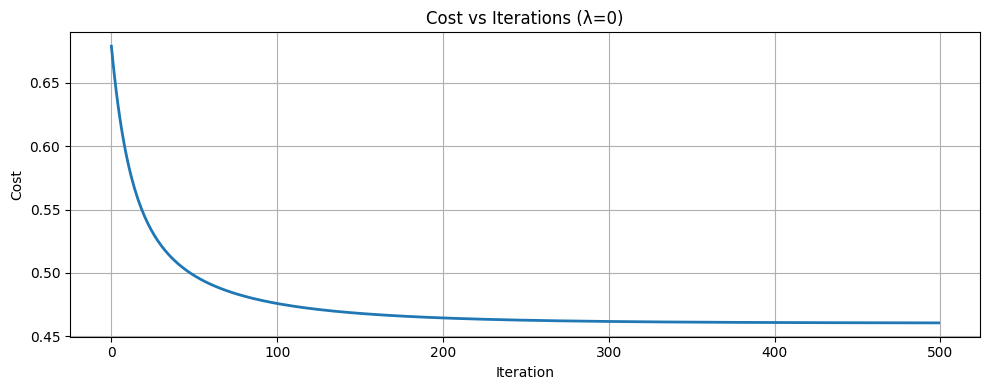

In [15]:
m, n = X_train.shape
w_init = np.zeros(n)
b_init = 0.0

print("Training baseline model (λ=0)...")
w_baseline, b_baseline, J_hist_baseline = gradient_descent_log_reg_reg(
    X_train, y_train, w_init, b_init, alpha=0.1, lam=0.0, num_iters=500, print_every=100
)

# Plot convergence
plt.figure(figsize=(10, 4))
plt.plot(J_hist_baseline, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iterations (λ=0)')
plt.tight_layout()
plt.show()

## 5. Ajuste de la Regularización (*Tuning*)

**Objetivo y método:**
- Entrenamos el mismo modelo con varias intensidades de regularización L2 ($\lambda$) y comparamos el rendimiento de entrenamiento frente al de prueba para seleccionar el mejor equilibrio (en este caso, usamos el **F1-score** de prueba).
- La regularización penaliza los pesos grandes, lo que reduce la **varianza** del modelo a expensas de un poco de **sesgo** (*bias*).

**Evidencia de sobreajuste (qué observar):**
- **Brecha en las métricas:** Si el F1/precisión de entrenamiento es mucho mayor que el de prueba, el modelo está sobreajustando el ruido del entrenamiento.
- **Norma de los pesos:** Un `||w||` grande suele indicar un modelo más complejo; la regularización debería reducir `||w||` y mitigar el overfitting.
- **Fronteras de decisión:** En las visualizaciones 2D, los modelos sobreajustados muestran fronteras onduladas o complejas que intentan ajustarse a puntos aislados; una regularización más fuerte suaviza estas fronteras.

**Enlaces a los cuadernos de clase para referencia:**
- El cuaderno `ClassificationAndLogisticRegression/APENDIX-RidgeVsGradientDescentInRegularizedLinearRegression.ipynb` demuestra cómo L2 (Ridge) afecta el decaimiento de los pesos (*weight decay*) y la convergencia.
- El cuaderno `ClassificationAndLogisticRegression/week2_classification_hour2_regularization_with_derivatives.ipynb` contiene las derivaciones y gráficas que muestran cómo cambian los gradientes al añadir el término de regularización.

**Consejos de interpretación:**
- Prefiere el $\lambda$ que reduzca la brecha entre entrenamiento y prueba manteniendo un F1 de prueba alto; valores de $\lambda$ extremos (demasiado grandes) causan **infraajuste** (*underfitting*), resultando en puntajes bajos tanto en entrenamiento como en prueba.
- Utiliza las gráficas de convergencia de costo junto con las de la norma `||w||` para comprender el efecto total de la regularización.

In [16]:
def predict(w, b, X):
    """Binary predictions."""
    z = X @ w + b
    return (sigmoid(z) >= 0.5).astype(int)

# Test different lambda values
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
results = {}

print("\nTuning regularization parameter λ...\n")

for lam in lambdas:
    print(f"Training with λ = {lam}...")
    w, b, J_hist = gradient_descent_log_reg_reg(
        X_train, y_train, w_init, b_init, alpha=0.1, lam=lam, num_iters=500, print_every=0
    )
    
    # Evaluate
    y_train_pred = predict(w, b, X_train)
    y_test_pred = predict(w, b, X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    results[lam] = {
        'w': w, 'b': b, 'J_hist': J_hist,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'weight_norm': np.linalg.norm(w)
    }
    
    print(f"  Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, F1: {test_f1:.4f}\n")

# Find best lambda
best_lam = max(lambdas, key=lambda lam: results[lam]['test_f1'])
print(f"✓ Best λ (by test F1): {best_lam}")


Tuning regularization parameter λ...

Training with λ = 0.0...
  Train Acc: 0.7937, Test Acc: 0.7407, F1: 0.7123

Training with λ = 0.001...
  Train Acc: 0.7937, Test Acc: 0.7407, F1: 0.7123

Training with λ = 0.01...
  Train Acc: 0.7937, Test Acc: 0.7407, F1: 0.7123

Training with λ = 0.1...
  Train Acc: 0.7937, Test Acc: 0.7407, F1: 0.7123

Training with λ = 1.0...
  Train Acc: 0.8042, Test Acc: 0.7407, F1: 0.7123

✓ Best λ (by test F1): 0.0


## 6. Visualizar Resultados

**Resumen y análisis:**
En esta sección presentamos tablas comparativas y gráficos que resumen el rendimiento del modelo según diferentes valores de regularización ($\lambda$).
- La tabla `comparison_df` compara precisión y F1 en *train/test* y la norma de los pesos para cada $\lambda$ evaluado.
- Los gráficos muestran: `Test Accuracy vs λ`, `Test F1 vs λ`, `||w|| vs λ` y la convergencia del costo por iteración para cada $\lambda$.

**Interpretación rápida:**
- **Brecha de métricas:** Un aumento en la diferencia entre entrenamiento y prueba sugiere *overfitting*.
- **Contracción de pesos:** Una disminución de $||w||$ conforme $\lambda$ crece indica que la regularización L2 está cumpliendo su función de contraer los pesos.
- **Punto óptimo:** Buscamos el $\lambda$ que maximiza la métrica F1 en el conjunto de prueba sin causar una caída pronunciada en la capacidad del modelo (*underfitting*).

In [17]:
# Comparison table
comparison_data = []
for lam in lambdas:
    comparison_data.append({
        'λ': lam,
        'Train Acc': results[lam]['train_acc'],
        'Test Acc': results[lam]['test_acc'],
        'Test F1': results[lam]['test_f1'],
        '||w||': results[lam]['weight_norm']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nResults Summary:")
print(comparison_df.to_string(index=False))


Results Summary:
    λ  Train Acc  Test Acc  Test F1    ||w||
0.000   0.793651  0.740741 0.712329 1.751749
0.001   0.793651  0.740741 0.712329 1.751628
0.010   0.793651  0.740741 0.712329 1.750533
0.100   0.793651  0.740741 0.712329 1.739685
1.000   0.804233  0.740741 0.712329 1.640484


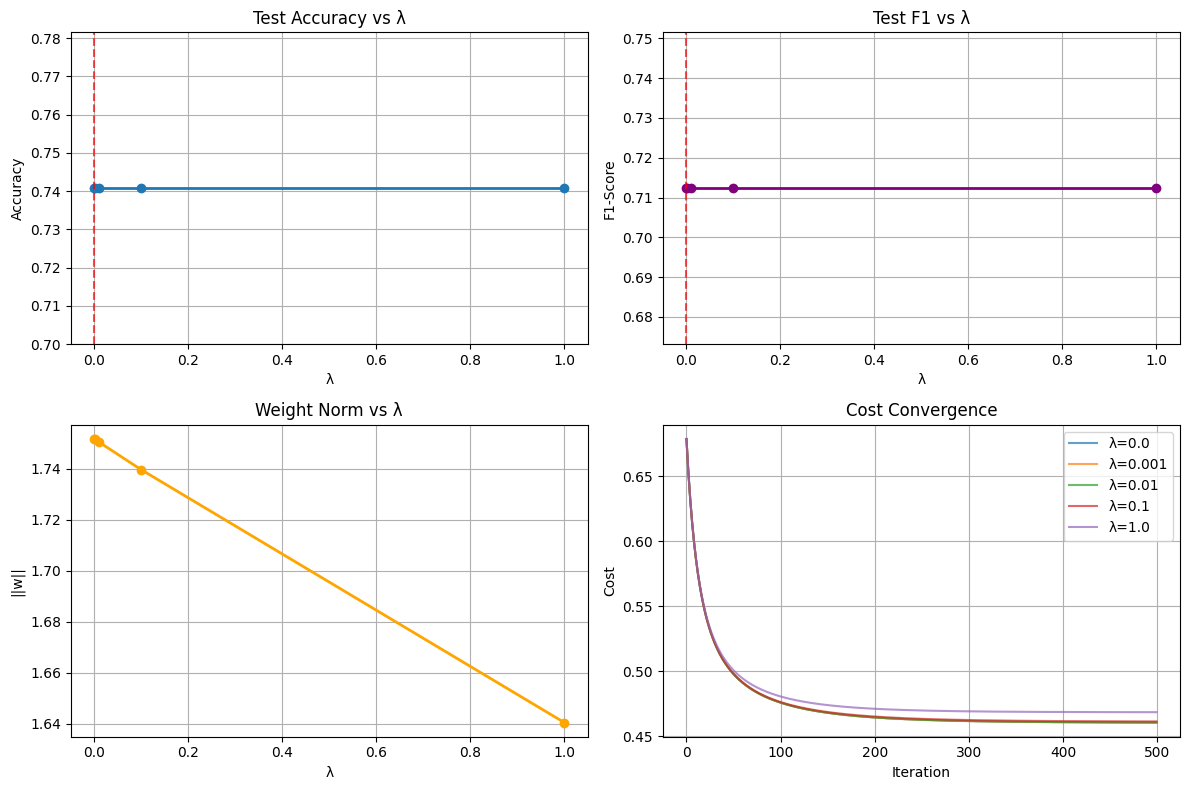

In [18]:
# Plot metrics vs lambda
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Test Accuracy
axes[0, 0].plot(lambdas, [results[lam]['test_acc'] for lam in lambdas], 'o-', linewidth=2)
axes[0, 0].set_xlabel('λ')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Test Accuracy vs λ')
axes[0, 0].axvline(best_lam, color='red', linestyle='--', alpha=0.7)

# Test F1
axes[0, 1].plot(lambdas, [results[lam]['test_f1'] for lam in lambdas], 'o-', linewidth=2, color='purple')
axes[0, 1].set_xlabel('λ')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('Test F1 vs λ')
axes[0, 1].axvline(best_lam, color='red', linestyle='--', alpha=0.7)

# Weight Norm
axes[1, 0].plot(lambdas, [results[lam]['weight_norm'] for lam in lambdas], 'o-', linewidth=2, color='orange')
axes[1, 0].set_xlabel('λ')
axes[1, 0].set_ylabel('||w||')
axes[1, 0].set_title('Weight Norm vs λ')

# Cost convergence for different lambdas
for lam in lambdas:
    axes[1, 1].plot(results[lam]['J_hist'], label=f'λ={lam}', alpha=0.7)
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Cost')
axes[1, 1].set_title('Cost Convergence')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluación Final con el Mejor Modelo

Aquí evaluamos el modelo entrenado con el mejor valor de λ (según F1 en test).
- Calculamos métricas completas (accuracy, precision, recall, F1) en train y test para el modelo final.
- Mostramos la matriz de confusión en test y comentamos los falsos positivos/falsos negativos y su impacto clínico.
- Interpretación práctica: discutir si el balance entre precisión y recall es aceptable para una aplicación clínica (por ejemplo, priorizar recall si queremos detectar la mayoría de pacientes en riesgo).

In [19]:
# Best model
w_best = results[best_lam]['w']
b_best = results[best_lam]['b']

# Predictions
y_train_pred = predict(w_best, b_best, X_train)
y_test_pred = predict(w_best, b_best, X_test)

# Metrics
print(f"\n=== BEST MODEL (λ={best_lam}) ===")
print(f"\nTraining Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred):.4f}")

print(f"\nTest Set:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix (Test):")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")


=== BEST MODEL (λ=0.0) ===

Training Set:
  Accuracy:  0.7937
  Precision: 0.7971
  Recall:    0.6875
  F1-Score:  0.7383

Test Set:
  Accuracy:  0.7407
  Precision: 0.7879
  Recall:    0.6500
  F1-Score:  0.7123

Confusion Matrix (Test):
  TN: 34, FP: 7
  FN: 14, TP: 26


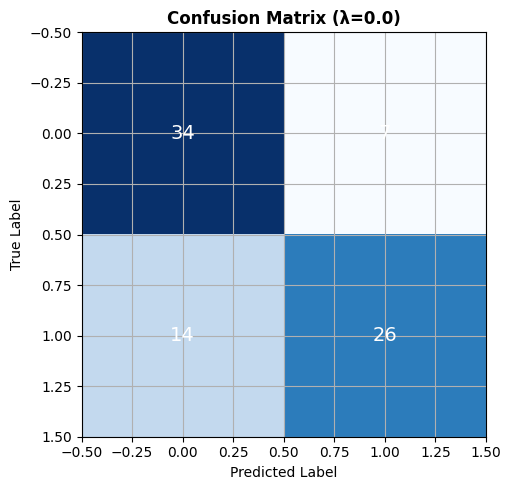

In [20]:
# Confusion matrix plot
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.imshow(cm, cmap='Blues')
ax.set_title(f'Confusion Matrix (λ={best_lam})', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white', fontsize=14)

plt.tight_layout()
plt.show()